# Week 06: Business Statistics & Analytics - E-commerce Analysis

## Learning Objectives
By the end of this exercise, you will be able to:
- Calculate key business metrics using pandas
- Create meaningful visualizations for business insights
- Apply statistical concepts to real business scenarios
- Make data-driven recommendations

---

## Business Context

You're working as a Data Analyst for **TechMart**, an e-commerce company. Your manager needs insights from last quarter's sales data to inform strategic decisions for the upcoming quarter.

Your analysis will help answer critical questions about customer behavior, regional performance, and product trends that directly impact business growth.

## Dataset Setup

First, let's generate the synthetic dataset you'll be analyzing:

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducible results
np.random.seed(42)

# Generate 500 orders from 2023
n_orders = 500

# Create order IDs and customer data
order_id = np.arange(1, n_orders + 1)
customer_id = np.random.randint(1, 101, size=n_orders)
customer_segment = np.random.choice(["Student", "Professional", "Senior"], size=n_orders, p=[0.4, 0.4, 0.2])
region = np.random.choice(["North", "South", "East", "West"], size=n_orders)
order_date = pd.date_range(start="2023-01-01", periods=n_orders, freq="D")
product_category = np.random.choice(["Electronics", "Clothing", "Books", "Home", "Sports"], size=n_orders)
quantity = np.random.randint(1, 5, size=n_orders)
unit_price = np.round(np.random.uniform(10, 200, size=n_orders), 2)
revenue = quantity * unit_price
discount_applied = np.random.choice([0, 5, 10, 15, 20, 25, 30], size=n_orders, p=[0.5,0.1,0.1,0.1,0.05,0.05,0.1])
payment_method = np.random.choice(["Credit Card", "PayPal", "Gift Card", "Debit Card"], size=n_orders)

# Build dataframe
df = pd.DataFrame({
    "order_id": order_id,
    "customer_id": customer_id,
    "customer_segment": customer_segment,
    "region": region,
    "order_date": order_date,
    "product_category": product_category,
    "quantity": quantity,
    "unit_price": unit_price,
    "revenue": revenue,
    "discount_applied": discount_applied,
    "payment_method": payment_method
})

# Save dataset for reference
df.to_csv("ecommerce_data.csv", index=False)
print("✅ Dataset created successfully!")

# Display first few rows
df.head()

✅ Dataset created successfully!


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


## Data Exploration

Let's start by understanding our dataset:

In [5]:
# Load the data
data = pd.read_csv("ecommerce_data.csv")

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nDataset Shape:", data.shape)
print("\nFirst few rows:")
data.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   customer_segment  500 non-null    object 
 3   region            500 non-null    object 
 4   order_date        500 non-null    object 
 5   product_category  500 non-null    object 
 6   quantity          500 non-null    int64  
 7   unit_price        500 non-null    float64
 8   revenue           500 non-null    float64
 9   discount_applied  500 non-null    int64  
 10  payment_method    500 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB
None

Dataset Shape: (500, 11)

First few rows:


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


Monthly Revenue:
month
2023-01    6626.66
2023-02    6796.03
2023-03    8960.10
2023-04    7713.47
2023-05    7266.80
2023-06    7982.47
2023-07    7981.65
2023-08    6664.64
2023-09    9708.06
2023-10    7287.27
2023-11    8795.85
2023-12    8119.44
2024-01    7268.59
2024-02    8388.91
2024-03    6835.73
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64


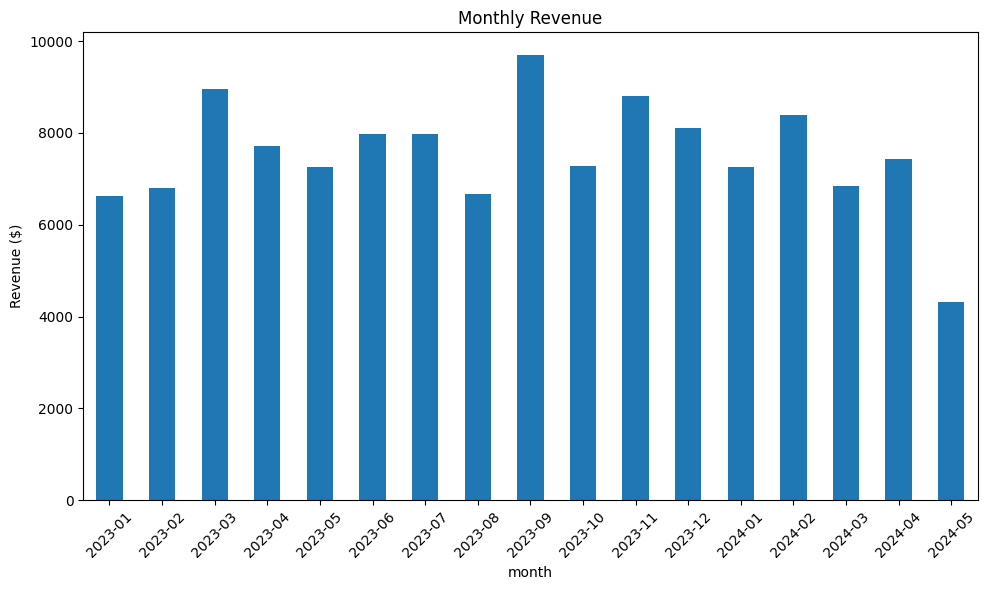

In [6]:
# Convert order_date to datetime and add helpful columns
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data["day_of_week"] = data["order_date"].dt.day_name()

# Example: Revenue by month
monthly_revenue = data.groupby("month")["revenue"].sum()
print("Monthly Revenue:")
print(monthly_revenue)

# Plot monthly revenue
monthly_revenue.plot(kind="bar", figsize=(10,6), title="Monthly Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Business Questions

Now answer each of the following business questions. Use the starter code above as a reference, and expand your analysis to solve all questions.

### 1. Revenue Overview
What was the company's total revenue last quarter? Break it down by month.

Last quarter: 2024Q2

Revenue by month in last quarter:
order_date
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64

Total revenue last quarter: $11745.00


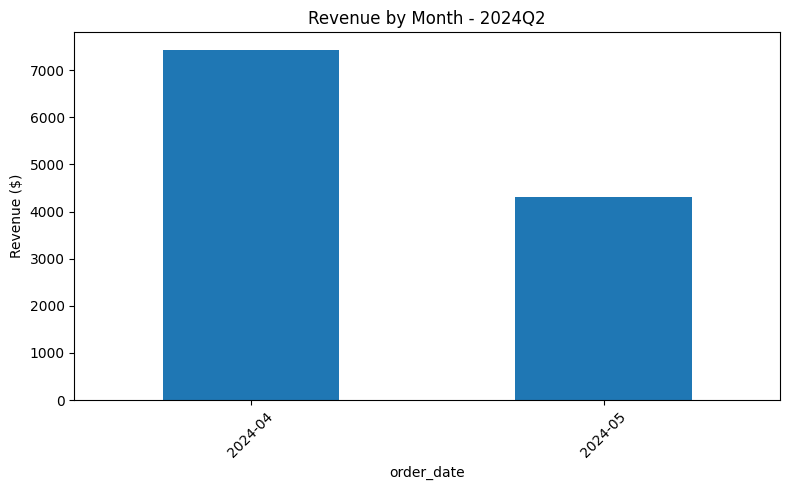

In [7]:
# Your code here
last_date = data["order_date"].max()
last_q = last_date.to_period("Q")
q_mask = data["order_date"].dt.to_period("Q") == last_q
last_quarter = data.loc[q_mask].copy()

rev_by_month = last_quarter.groupby(last_quarter["order_date"].dt.to_period("M"))["revenue"].sum().sort_index()
total_rev_last_q = rev_by_month.sum()

print("Last quarter:", str(last_q))
print("\nRevenue by month in last quarter:")
print(rev_by_month)

print("\nTotal revenue last quarter: $%.2f" % total_rev_last_q)

# Plot
rev_by_month.plot(kind="bar", figsize=(8,5), title=f"Revenue by Month - {last_q}")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Top Customers
Who are the top 5 customers by total revenue contribution?

In [8]:
# Your code here
top_customers = (data.groupby("customer_id")["revenue"]
                   .sum()
                   .sort_values(ascending=False)
                   .head(5))
print("Top 5 customers by revenue:")
print(top_customers)


Top 5 customers by revenue:
customer_id
62    4448.39
24    3369.44
90    2976.78
92    2838.74
97    2835.62
Name: revenue, dtype: float64


### 3. Segment Analysis
Which customer segment (Student, Professional, Senior) spends the most on average per order?

In [9]:
# Your code here
avg_by_segment = data.groupby("customer_segment")["revenue"].mean().sort_values(ascending=False)
print("Average revenue per order by segment:")
print(avg_by_segment)
print("\nTop segment:", avg_by_segment.idxmax())

Average revenue per order by segment:
customer_segment
Senior          262.133925
Professional    255.652674
Student         253.812087
Name: revenue, dtype: float64

Top segment: Senior


### 4. Regional Trends
Which region generated the highest revenue? Which region had the highest average order size?

In [10]:
# Your code here
rev_by_region = data.groupby("region")["revenue"].sum().sort_values(ascending=False)
avg_order_value_by_region = data.groupby("region")["revenue"].mean().sort_values(ascending=False)
avg_qty_by_region = data.groupby("region")["quantity"].mean().sort_values(ascending=False)

print("Revenue by region:")
print(rev_by_region)
print("\nAverage order value by region:")
print(avg_order_value_by_region)
print("\nAverage quantity per order by region:")
print(avg_qty_by_region)

print("\nTop revenue region:", rev_by_region.idxmax())
print("Top average order value region:", avg_order_value_by_region.idxmax())

Revenue by region:
region
South    34839.45
North    34351.69
East     31221.80
West     27727.73
Name: revenue, dtype: float64

Average order value by region:
region
South    274.326378
North    258.283383
West     252.070273
East     240.167692
Name: revenue, dtype: float64

Average quantity per order by region:
region
West     2.627273
East     2.469231
South    2.440945
North    2.360902
Name: quantity, dtype: float64

Top revenue region: South
Top average order value region: South


### 5. Product Category Performance
Which product category is most popular by quantity vs. by revenue?

In [11]:
# Your code here
qty_by_cat = data.groupby("product_category")["quantity"].sum().sort_values(ascending=False)
rev_by_cat = data.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

print("Total quantity by category:")
print(qty_by_cat)
print("\nTotal revenue by category:")
print(rev_by_cat)

print("\nMost popular by quantity:", qty_by_cat.idxmax())
print("Top by revenue:", rev_by_cat.idxmax())

Total quantity by category:
product_category
Home           269
Clothing       253
Sports         246
Electronics    239
Books          227
Name: quantity, dtype: int64

Total revenue by category:
product_category
Home           29871.47
Electronics    25498.31
Clothing       24804.57
Books          24046.06
Sports         23920.26
Name: revenue, dtype: float64

Most popular by quantity: Home
Top by revenue: Home


### 6. Discount Effectiveness
Do discounted orders generate higher or lower revenue per order compared to non-discounted orders?

In [12]:
# Your code here
discounted = data["discount_applied"] > 0
avg_rev_discounted = data.loc[discounted, "revenue"].mean()
avg_rev_nodiscount = data.loc[~discounted, "revenue"].mean()

print("Average revenue per order (discounted): $%.2f" % avg_rev_discounted)
print("Average revenue per order (no discount): $%.2f" % avg_rev_nodiscount)

# Simple comparison
if avg_rev_discounted > avg_rev_nodiscount:
    print("→ Discounted orders have HIGHER average revenue per order.")
elif avg_rev_discounted < avg_rev_nodiscount:
    print("→ Discounted orders have LOWER average revenue per order.")
else:
    print("→ Discounted and non-discounted orders have the SAME average revenue per order.")

Average revenue per order (discounted): $263.83
Average revenue per order (no discount): $248.30
→ Discounted orders have HIGHER average revenue per order.


### 7. Payment Method Usage
What percentage of orders use each payment method? Does any payment method correlate with higher spending?

In [13]:
# Your code here
method_counts = data["payment_method"].value_counts(normalize=True) * 100
print("Payment method usage (% of orders):")
print(method_counts.round(2))

avg_by_method = data.groupby("payment_method")["revenue"].mean().sort_values(ascending=False)
print("\nAverage revenue per order by payment method:")
print(avg_by_method)
print("\nTop-spending method:", avg_by_method.idxmax())

Payment method usage (% of orders):
payment_method
Credit Card    27.4
Gift Card      24.8
Debit Card     24.6
PayPal         23.2
Name: proportion, dtype: float64

Average revenue per order by payment method:
payment_method
Debit Card     275.980650
Credit Card    257.444234
Gift Card      254.362500
PayPal         236.071034
Name: revenue, dtype: float64

Top-spending method: Debit Card


### 8. Seasonality Check
Plot revenue by day of week — are weekends busier than weekdays?

Revenue by day of week:
day_of_week
Monday       17704.70
Tuesday      18968.41
Wednesday    18908.21
Thursday     17846.36
Friday       18522.40
Saturday     18660.35
Sunday       17530.24
Name: revenue, dtype: float64


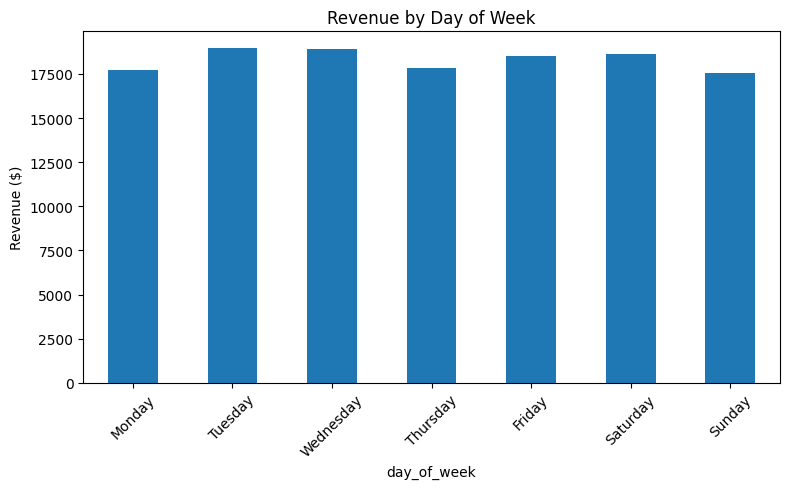


Weekend vs Weekday revenue: $36190.59 vs $91950.08
Weekends busier? False


In [14]:
# Your code here
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_rev = (data.groupby("day_of_week")["revenue"]
             .sum()
             .reindex(order))
print("Revenue by day of week:")
print(dow_rev)

dow_rev.plot(kind="bar", figsize=(8,5), title="Revenue by Day of Week")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

weekend = dow_rev.loc[["Saturday","Sunday"]].sum()
weekday = dow_rev.loc[["Monday","Tuesday","Wednesday","Thursday","Friday"]].sum()
print("\nWeekend vs Weekday revenue: $%.2f vs $%.2f" % (weekend, weekday))
print("Weekends busier?", weekend > weekday)

### 9. Profitability (Stretch)
Assume profit margin = 20% of revenue. Estimate total profit and identify the most profitable region.

In [15]:
# Your code here
data["profit"] = data["revenue"] * 0.20
total_profit = data["profit"].sum()
profit_by_region = data.groupby("region")["profit"].sum().sort_values(ascending=False)

print("Estimated total profit: $%.2f" % total_profit)
print("\nProfit by region:")
print(profit_by_region)
print("\nMost profitable region:", profit_by_region.idxmax())

Estimated total profit: $25628.13

Profit by region:
region
South    6967.890
North    6870.338
East     6244.360
West     5545.546
Name: profit, dtype: float64

Most profitable region: South


### 10. Business Recommendation
Based on your findings, recommend one strategy (e.g., focus on certain customer segments, increase discounts, promote specific regions/products).

**Your recommendation here:**

Run targeted promotions for Home (top category) and tailor offers to the Senior segment, which spends the most per order. 


---

## Submission Requirements

1. **Complete code** for all 10 questions
2. **Clear visualizations** where appropriate  
3. **Brief interpretation** of each result
4. **Final business recommendation** with supporting data

Remember: Focus on what the numbers tell us about the business, not just the calculations themselves.